# Student Performance Exploratory Data Analysis
The goal of this notebook is to explore the factors affecting students' final grades and prepare the data for future modeling.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('Student_Performance.csv') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [4]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [5]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


We want to see how study hours affect the final grade.

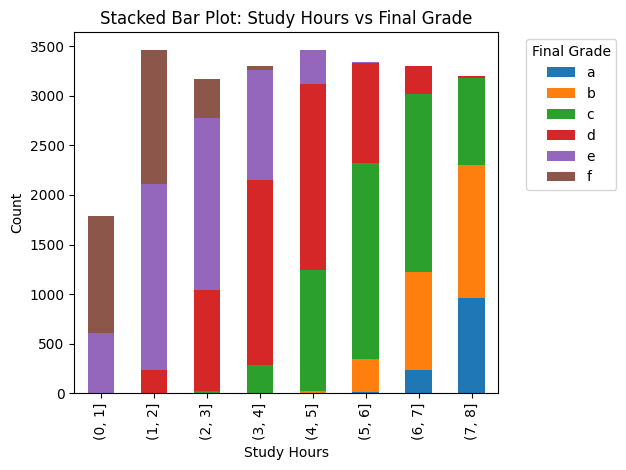

In [ ]:
study_hours_bins = pd.cut(df['study_hours'], bins=range(0, 12, 1))
pd.crosstab(study_hours_bins, df['final_grade']).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Plot: Study Hours vs Final Grade')
plt.xlabel('Study Hours')
plt.ylabel('Count')
plt.legend(title='Final Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

As we can see the more you study the better grade you get.

___________________________________________________________________

We'll now look at the relationship between attendance and the final grade.

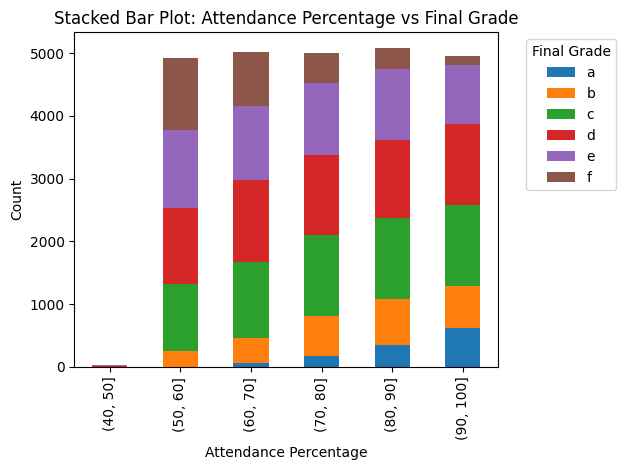

In [60]:
attendance_bins = pd.cut(df['attendance_percentage'], bins=range(0, 101, 10))
pd.crosstab(attendance_bins, df['final_grade']).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Plot: Attendance Percentage vs Final Grade')
plt.xlabel('Attendance Percentage')
plt.ylabel('Count')
plt.legend(title='Final Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Here too we can see a light relationship with attendance and the final grade.

___________________________________________________________________

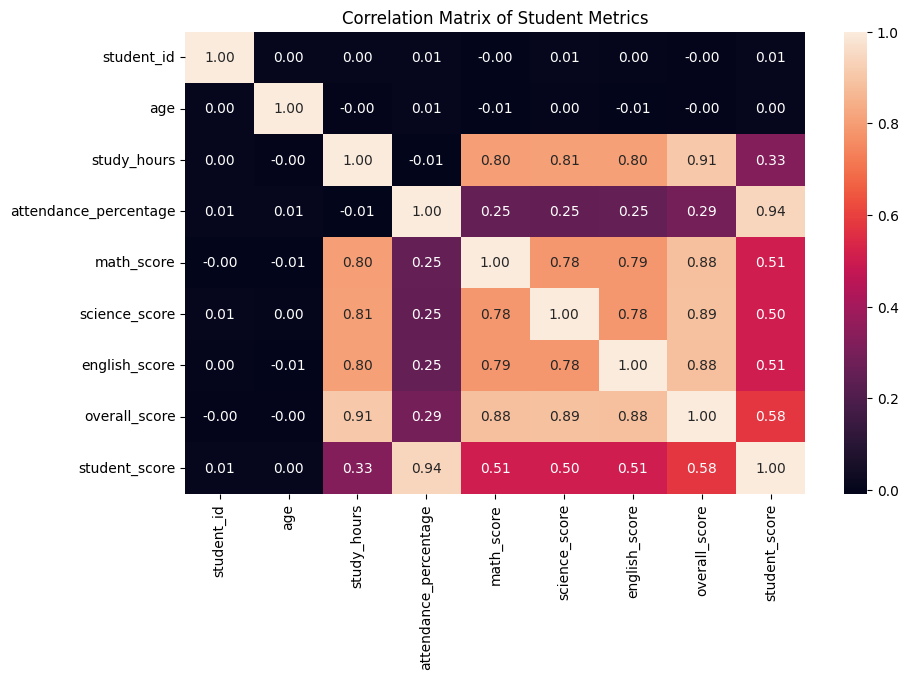

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix of Student Metrics')
plt.show()

Since we can see a clear relationship between study time and attendance with the final grade, I want to visualize this relationship using a scatterplot.

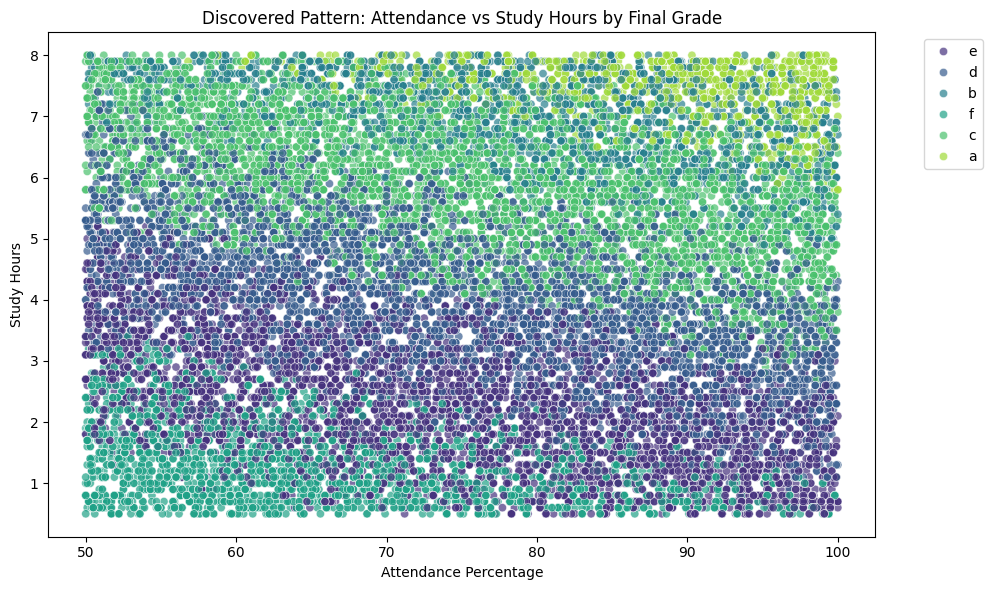

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='attendance_percentage', 
    y='study_hours', 
    hue='final_grade', 
    palette='viridis',
    alpha=0.7
)
plt.title('Discovered Pattern: Attendance vs Study Hours by Final Grade')
plt.xlabel('Attendance Percentage')
plt.ylabel('Study Hours')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

As we can see from the scatterplot theres an obvious linear relationship between the 2. Since the boundaries are so clear, we will use a decision tree.

In [99]:
X = df[['study_hours', 'attendance_percentage']]
y = df['final_grade']

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(min_samples_leaf=15, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)


Classification Report:
              precision    recall  f1-score   support

           a       0.58      0.57      0.58       256
           b       0.51      0.46      0.48       542
           c       0.64      0.68      0.66      1198
           d       0.66      0.64      0.65      1268
           e       0.66      0.68      0.67      1152
           f       0.72      0.71      0.71       584

    accuracy                           0.65      5000
   macro avg       0.63      0.62      0.63      5000
weighted avg       0.64      0.65      0.64      5000



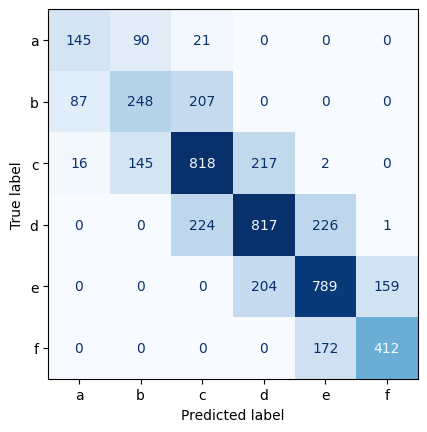

In [104]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap='Blues', colorbar=False)
print("\nClassification Report:")
print(classification_report(y_test, predictions))

As you can see from the confusion matrix its pretty accurate. with slight errors between boundaries like ed and e, However, thats mainly because they have a high count.

I decided to do some feature engineering to improve the results by creating a student score thats a combination of study hours and attendance percentage.

Feature Engineering: Split students into school levels based on age
#### 14-15 = Middle School, 16-19 = High School

In [75]:

df['school_level'] = df['age'].apply(lambda x: 'Middle School' if x <= 15 else 'High School')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

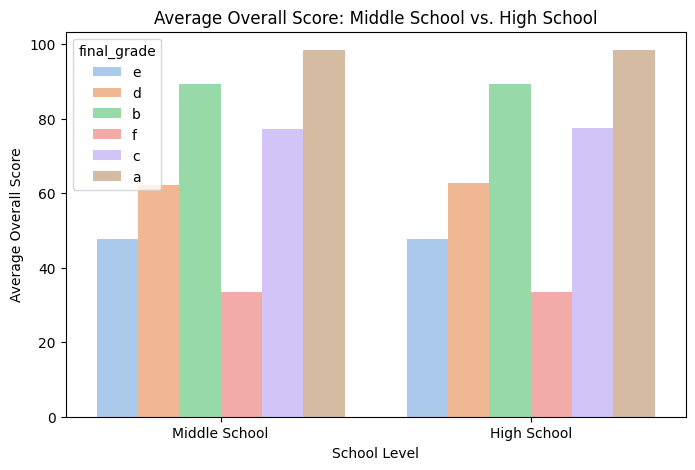

In [77]:
plt.figure(figsize=(8, 5))
sns.barplot(x='school_level', y='overall_score', data=df, errorbar=None, palette='pastel', hue='final_grade')
plt.title('Average Overall Score: Middle School vs. High School')
plt.xlabel('School Level')
plt.ylabel('Average Overall Score')
plt.show()

### Feature Engineering: School Level Classification
Since student performance and study habits often change as they grow older, I created`school_level to see this trend, however, it didnt exist.

In [82]:
df.drop(columns=['school_level'], inplace=True)

In [83]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade,student_score
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e,27.46
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d,28.93
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b,25.18
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e,18.20
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f,19.21


In [ ]:
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 0.6471
Testing Accuracy: 0.6394


In [106]:
X = df[['study_hours', 'attendance_percentage', 'math_score', 'english_score', 'science_score']]
y = df['final_grade']


Classification Report:
              precision    recall  f1-score   support

           a       0.87      0.80      0.83       256
           b       0.80      0.79      0.80       542
           c       0.87      0.89      0.88      1198
           d       0.88      0.88      0.88      1268
           e       0.88      0.89      0.89      1152
           f       0.91      0.89      0.90       584

    accuracy                           0.87      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.87      0.87      5000



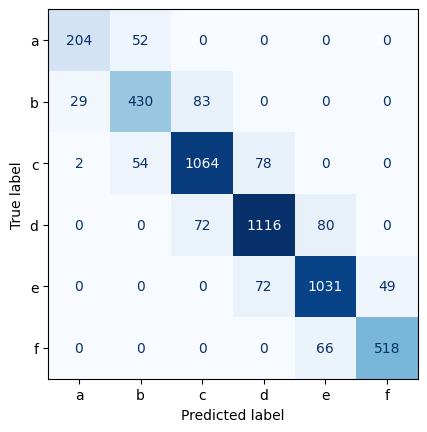

In [109]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap='Blues', colorbar=False)
print("\nClassification Report:")
print(classification_report(y_test, predictions))

In [ ]:
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8726
